In [1]:
import xarray as xr
import fsspec
import zarr

import numpy as np
import pandas as pd

import csv
import numpy as np
import matplotlib.pyplot as plt

import random
import os
from tqdm import tqdm
import gc
from pathlib import Path

In [2]:
ds = xr.open_dataset('./dataset_greece.nc')

In [4]:
ds.variables

Frozen({'burned_areas': <xarray.Variable (time: 4560, y: 983, x: 1253)> Size: 22GB
[5616547440 values with dtype=float32]
Attributes:
    units:      unitless
    long_name:  Rasterized burned polygons
    title:      EFFIS (https://effis.jrc.ec.europa.eu/) burned areas burned a..., 'ignition_points': <xarray.Variable (time: 4560, y: 983, x: 1253)> Size: 22GB
[5616547440 values with dtype=float32]
Attributes:
    units:      unitless
    long_name:  Rasterized ignition points
    title:      Ignition points burned as raster (value 1) on the map calcula..., 'ndvi': <xarray.Variable (time: 4560, y: 983, x: 1253)> Size: 22GB
[5616547440 values with dtype=float32]
Attributes:
    units:      unitless
    long_name:  16-day NDVI
    title:      Normalized Difference Vegetation Index - MODIS/Terra Vegetati..., 'number_of_fires': <xarray.Variable (time: 4560)> Size: 9kB
[4560 values with dtype=int16]
Attributes:
    units:      unitless
    long_name:  Daily number of fires
    title:      Da

In [6]:
ds

<xarray.Dataset> Size: 832GB
Dimensions:             (time: 4560, y: 983, x: 1253)
Coordinates:
  * time                (time) datetime64[ns] 36kB 2009-03-06T10:00:00 ... 20...
  * y                   (y) float64 8kB 42.3 42.29 42.28 ... 34.32 34.31 34.3
  * x                   (x) float64 10kB 18.7 18.71 18.72 ... 28.88 28.89 28.9
    band                int64 8B ...
    spatial_ref         int64 8B ...
Data variables: (12/90)
    burned_areas        (time, y, x) float32 22GB ...
    ignition_points     (time, y, x) float32 22GB ...
    ndvi                (time, y, x) float32 22GB ...
    number_of_fires     (time) int16 9kB ...
    evi                 (time, y, x) float32 22GB ...
    et                  (time, y, x) float32 22GB ...
    ...                  ...
    POP_DENS_2016       (y, x) float32 5MB ...
    POP_DENS_2017       (y, x) float32 5MB ...
    POP_DENS_2018       (y, x) float32 5MB ...
    POP_DENS_2019       (y, x) float32 5MB ...
    POP_DENS_2020       (y, x) float32 5MB ...
    POP_DENS_2021       (y, x) float32 5MB ...
Attributes:
    temporal_extent:   (2009-03-06, 2021-08-29)
    spatial_extent:    (18.7, 28.9, 34.3, 42.3)
    crs:               EPSG:4326
    license:           Creative Commons Attribution v4
    creators:          Ioannis Prapas, Spyros Kondylatos, Ioannis Papoutsis
    contact_person:    Ioannis Prapas <iprapas (at) noa.gr>
    citation:          Ioannis Prapas, Spyros Kondylatos, & Ioannis Papoutsis...
    acknowledgements:  This work has received funding from the European Union...
    title:             FireCube: A Daily Datacube for the Modeling and Analys...

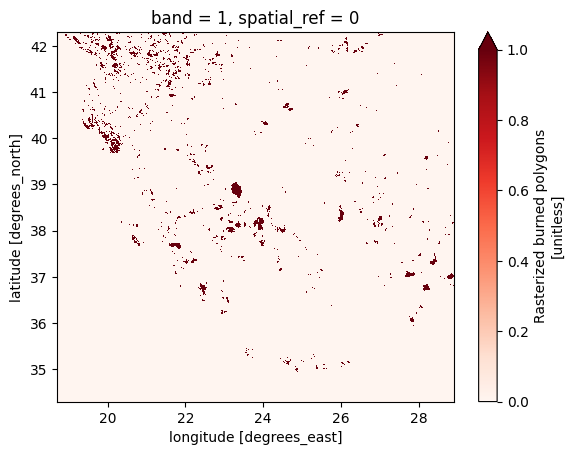

In [22]:
# 变量burned_areas 燃烧区域
# 查看历史上所有发生过火灾的区域叠加图
ds['burned_areas'].sum(dim='time').plot(cmap='Reds',vmin=0,vmax=1)

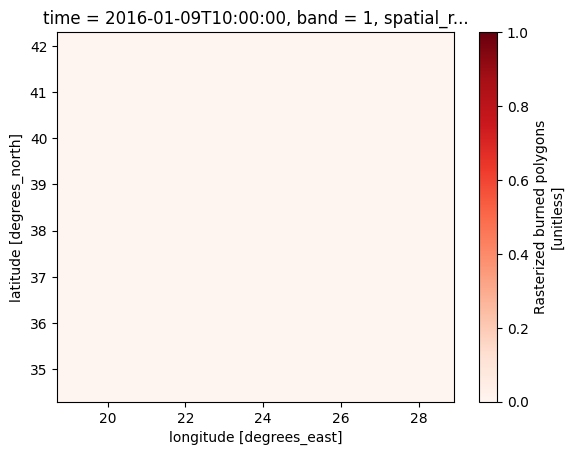

In [18]:
# 查看某一天的火灾区域图
ds['burned_areas'].isel(time=2500).plot(cmap='Reds', vmin=0, vmax=1)

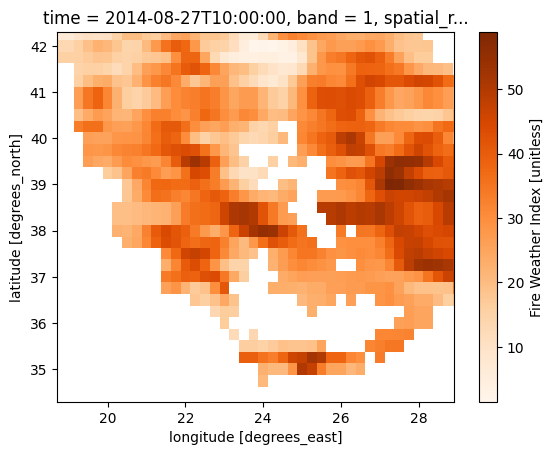

In [9]:
# 查看某一天的火险指数fwi
ds['fwi'].isel(time=2000).plot(cmap='Oranges')

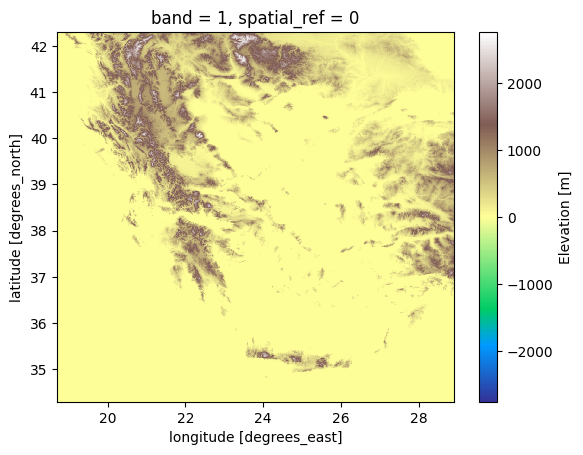

In [10]:
# 使用地形色谱绘制海拔 DEM表示海报高度
ds['DEM'].plot(cmap='terrain')

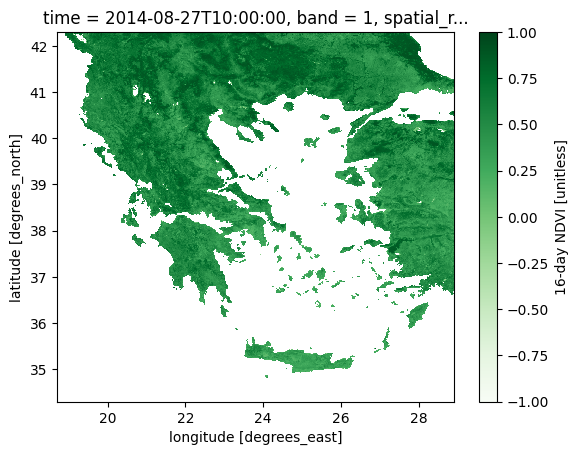

In [11]:
# 绿色越深代表植被越茂密
ds['ndvi'].isel(time=2000).plot(cmap='Greens')

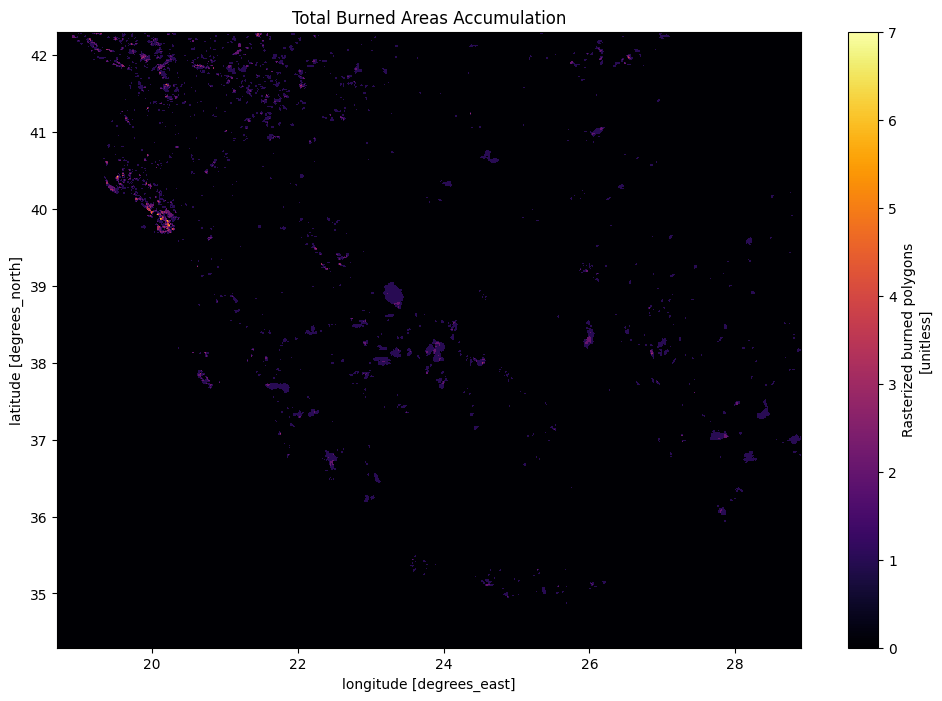

In [ ]:
plt.figure(figsize=(12, 8))
# 叠加所有时间的火灾区域
ds['burned_areas'].sum(dim='time').plot(cmap='inferno')
plt.title("Total Burned Areas Accumulation")
plt.show()

In [19]:
daily_burns = ds["burned_areas"].sum(dim=['x','y'])
worst_day_idx = daily_burns.argmax().item()

In [20]:
worst_day_idx

4532

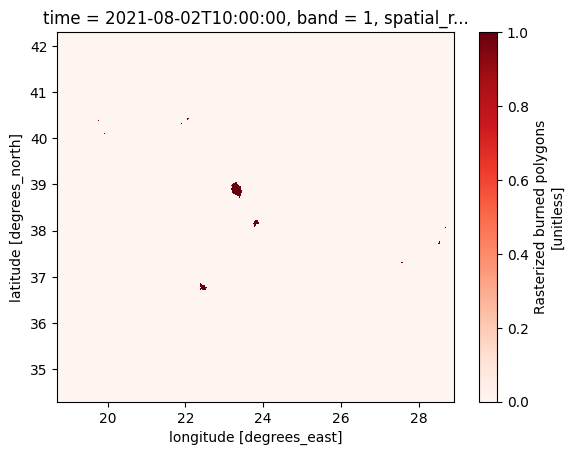

In [21]:
ds['burned_areas'].isel(time=4532).plot(cmap='Reds', vmin=0, vmax=1)

In [24]:
data_worst_day = ds['burned_areas'].isel(time=worst_day_idx)
burned_pixels = data_worst_day.sum().values
total_pixels = data_worst_day.size
percent = (burned_pixels / total_pixels) * 100
print(f"在火灾最严重的一天，燃烧面积占比仅为: {percent:.4f}%")

在火灾最严重的一天，燃烧面积占比仅为: 0.1150%
